In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

In [9]:
dir_old = "/Users/anzony.quisperojas/Library/CloudStorage/Dropbox/sa_fires"
shell = r'C:\Users\187697\Dropbox\sa_fires\proj_bureaucrats_farms'
dbox = r'/Users/anzony.quisperojas/Library/CloudStorage/Dropbox/sa_fires/proj_bureaucrats_farms'
old_prj = f"{dir_old}/proj_downwind/data_output/intermediate"
main = dbox
inter_path = f'{main}/data_output/intermediate'
figures = f"{main}/tex/paper/figures"


In [10]:
states = gpd.read_file(f'{dir_old}/data/input/admin-data/india/IND_adm/IND_adm1.shp')
st_sel = states.query('NAME_1.isin(["Bihar", "Uttar Pradesh", "Punjab", "Haryana"])')

df_grids_ac = pd.read_csv(f'{dbox}/data_output/intermediate/8_grids_ac_pr_5km.csv')
grds_ac = pd.read_csv( f'{dbox}/data_output/intermediate/_1_AC_grid_intersection.csv')
merge1 = grds_ac.merge(df_grids_ac, how = 'left')
merge1['protest_place']=merge1['protest_place'].replace(np.nan, 0)

acs_place = merge1.groupby(['ac_uq_id', 'protest_place'], as_index = False )['unique_small_grid_id'].count().reset_index() \
            .loc[:, ['index', 'ac_uq_id', 'protest_place']]
acs_place.columns = ['ac_area_tr', 'ac_uq_id', 'protest_place']

merge1 = merge1.merge(acs_place)
grids = gpd.read_file(f'{old_prj}/1-grid-generation.shp' )
grids.columns=['id', 'split_d', 'split', 'unique_small_grid_id', 'geometry']

merge1 = merge1.merge(grids)
merge1 = gpd.GeoDataFrame(merge1)

merge1['treat']=0
merge1.loc[ merge1.protest_place>0, 'treat']=1

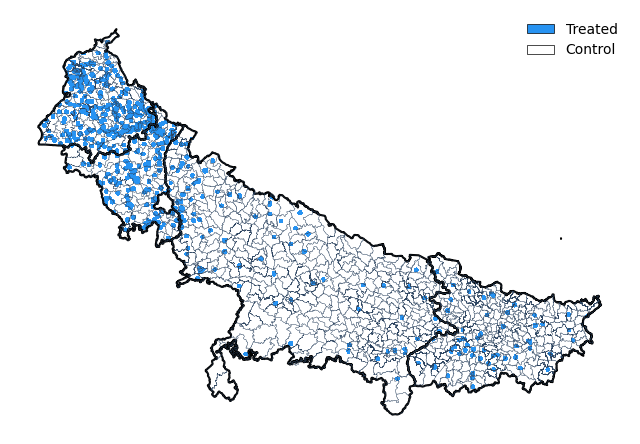

In [11]:
# create a helper color‐map column
merge1["plot_color"] = merge1["treat"].map({0: "white", 1: "#2793F2"})

fig, ax = plt.subplots(figsize=(8, 8))
acs = gpd.read_file(f'{dbox}/data_output/intermediate/_0_2_3_ACs_right_shapefile.shp')

st_sel.boundary.plot(ax=ax,color = 'black')
acs.boundary.plot(
    color="#2C4460",
    linewidth=0.2,
    edgecolor="blue",
    ax=ax
)
merge1.plot(ax=ax, color=merge1["plot_color"], edgecolor="none", linewidth=0 )

# build a manual legend
handles = [
    mpatches.Patch(facecolor="#2793F2", edgecolor="black", linewidth=0.5, label="Treated"),
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=0.5, label="Control"),
]
ax.legend(handles=handles, title="", loc="upper right", 
         frameon = False )


plt.title("")
plt.axis("off")
plt.show()


fig.savefig(f"{dbox}/tex/paper/figures/5km_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
protests = pd.read_csv( f'{dir_old}/data/input/acled/2000-01-01-2025-05-13-South_Asia-India.csv', sep = ';')
protests['event_date'] = pd.to_datetime(protests['event_date'], dayfirst=True)

# Define date range
start_date = pd.to_datetime('2020-06-01')
end_date = pd.to_datetime('2021-12-09')
filtered_protests = protests[(protests['event_date'] >= start_date) & 
                             (protests['event_date'] <= end_date)].copy()

/var/folders/gb/56xms55d53n734tnp7xq55bh0000gq/T/ipykernel_66028/2568559647.py:1: DtypeWarning: Columns (11,26) have mixed types. Specify dtype option on import or set low_memory=False.
  protests = pd.read_csv( f'{dir_old}/data/input/acled/2000-01-01-2025-05-13-South_Asia-India.csv', sep = ';')


In [14]:
filtered_protests['assoc_actor_1'] = filtered_protests['assoc_actor_1'].str.lower()
mask = filtered_protests['assoc_actor_1'].str.lower().str.contains(r'\bfarm\w*', na=False)
mask2 = filtered_protests['notes'].str.lower().str.contains(r'\bfarm\w*', na=False)
filtered_protests_type = filtered_protests[mask | mask2].copy()


In [15]:
filtered_protests_not = filtered_protests[~(mask|mask2)].copy()
filtered_protests_not['year_month'] = filtered_protests_not['event_date'].dt.to_period('M')


In [16]:
# Create a 'year-month' column
filtered_protests_type['year_month'] = filtered_protests_type['event_date'].dt.to_period('M')



In [17]:
# Count observations per month
monthly_counts = filtered_protests_type[['year_month', 'admin1']].drop_duplicates()['year_month'] \
                             .value_counts().sort_index()

# Convert PeriodIndex to datetime for plotting
monthly_counts.index = monthly_counts.index.to_timestamp()


In [21]:
monthly_counts.sum()

np.int64(390)

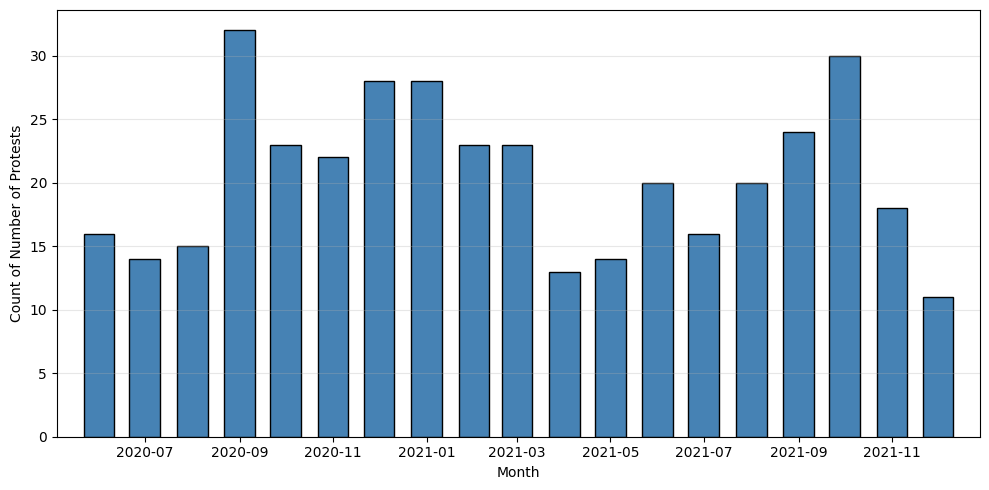

In [11]:
# Plot as bar chart
plt.figure(figsize=(10,5))
plt.bar(monthly_counts.index, monthly_counts.values, 
        color='steelblue', edgecolor='black', width=20)

# plt.title("Monthly Number of Distinct Protest Events")
plt.xlabel("Month")
plt.ylabel("Count of Number of Protests")
plt.grid(alpha=0.3, axis='y')

# Add a small margin on both sides (5% of total range)
x_min, x_max = monthly_counts.index.min(), monthly_counts.index.max()
x_range = x_max - x_min
plt.xlim(x_min - x_range * 0.05, x_max + x_range * 0.05 )

# Hide any tick labels that fall outside data range
plt.tick_params(axis='x', which='both', labelbottom=True)
plt.tight_layout()
# Save and show
plt.savefig(f"{main}/tex/paper/figures/protests_monthly_bars.png", dpi=300)
plt.show()

In [12]:
acs = gpd.read_file('../../data_output/intermediate/_0_2_3_ACs_right_shapefile.shp')
acs['area_ac'] = acs.to_crs(7755).area

In [13]:
# Replace with actual column names if different
geometry = gpd.points_from_xy(filtered_protests_type.longitude, filtered_protests_type.latitude)

# Create GeoDataFrame with WGS84 CRS
protest_info = gpd.GeoDataFrame(filtered_protests_type, geometry=geometry, crs="EPSG:4326")

In [14]:
acs_pro = gpd.overlay(protest_info,acs, keep_geom_type=True)
acs_pro = acs_pro.reset_index(drop=True).reset_index().rename(columns={'index':'protest_id'})


In [15]:
npros_byac = acs_pro.groupby('ac_uq_id').size().reset_index().rename(columns = {0:'npros'})

In [16]:
ac_sel = 285
geom = acs_pro.query(f'ac_uq_id == {ac_sel}').copy()
# Project to meters
geom_proj = geom.to_crs(epsg=7755)

# Buffer in meters (dist_km assumed to be defined already)
geom_proj['geometry'] = geom_proj.geometry.buffer(5 * 1000)

# Reproject back to WGS84
geom_proj = geom_proj.to_crs(epsg=4326)
# geom_proj.plot()


In [17]:
geom_proj_aux = geom_proj.drop_duplicates(['latitude', 'longitude'])

In [18]:
acs.query(f'ac_uq_id == {ac_sel}')

,ac_uq_id,STATE_UT,DISTRICT,ASSEMBLY_1,ASSEMBLY,acpost08ID,geometry,area_ac
784,285,HARYANA,JIND,JIND,36.0,2714.0,"POLYGON ((76.43832 29.3486, 76.42685 29.34241,...",2.144403e+08


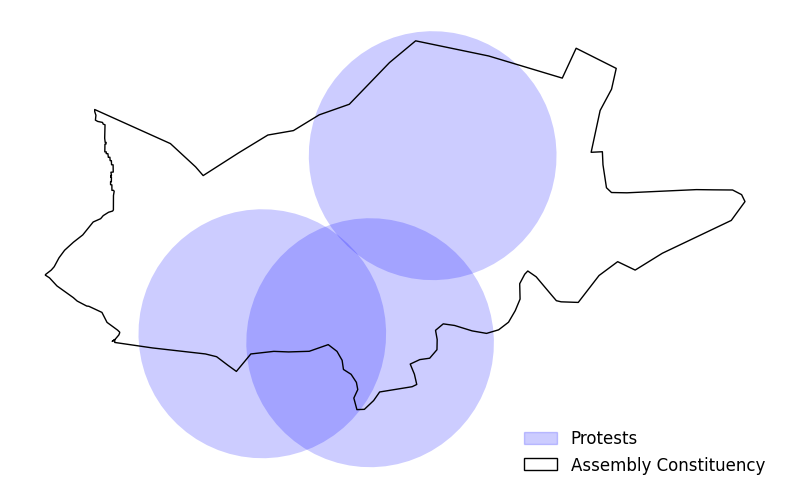

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(8, 8))

# 1. Plot protest boundaries (blue)
geom_proj_aux.plot(ax=ax, color='blue', linewidth=0.7, label='Protests', alpha = 0.2)

# 2. Plot Assembly Constituency with ac_uq_id == 251 (black)
acs.query(f'ac_uq_id == {ac_sel}').boundary.plot(ax=ax, color='black', linewidth=1.0, label='Assembly Constituency')

# 3. Legend & formatting
# ax.legend(facecolor='white', edgecolor='black', fontsize=10,  )
# ax.legend(
#     loc='lower right',           # bottom-right corner
#     fontsize=12,
#     frameon=False
# )
protests_patch = mpatches.Patch(color='blue', alpha=0.2, label='Protests')
ac_patch = mpatches.Patch(edgecolor='black', facecolor='none', label='Assembly Constituency')
ax.legend(
    handles=[protests_patch, ac_patch],
    loc='lower right',
    fontsize=12,
    frameon=False
)

# ax.set_title("Protests and Assembly Constituency 251", fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig(f"{figures}/ac_protest_plot.png", dpi=300)

plt.show()


In [20]:
ac_list = acs_pro.ac_uq_id.unique().tolist()

In [21]:
from shapely.geometry import Polygon, MultiPolygon
import geopandas as gpd
import pandas as pd

# Example list of ac_uq_ids to loop through
buffer_results = []
dist_km = 5
for ac_val in ac_list:
    geom = acs_pro.query(f'ac_uq_id == {ac_val}').copy()
    if geom.empty:
        continue

    # Project to meters
    geom_proj = geom.to_crs(epsg=7755)

    # Buffer in meters (dist_km assumed to be defined already)
    geom_proj['geometry'] = geom_proj.geometry.buffer(dist_km * 1000)

    # Reproject back to WGS84
    geom_proj = geom_proj.to_crs(epsg=4326)

    # Intersect with acs
    intersected = gpd.overlay(acs, geom_proj, how='intersection')

    if intersected.empty:
        continue

    # Union all geometries to get single (multi)polygon
    unified = intersected.unary_union

    # Convert to GeoSeries for exploding
    if isinstance(unified, Polygon):
        gdf = gpd.GeoDataFrame(geometry=[unified], crs=acs.crs)
    elif isinstance(unified, MultiPolygon):
        gdf = gpd.GeoDataFrame(geometry=list(unified.geoms), crs=acs.crs)
    else:
        continue  # skip unexpected geometry

    # Optionally add identifier column
    gdf['ac_uq_id'] = ac_val

    # Append to list
    buffer_results.append(gdf)

# Combine all into a single GeoDataFrame
buffer_combined = pd.concat(buffer_results, ignore_index=True)

# Optional: reset geometry column if needed
buffer_combined = gpd.GeoDataFrame(buffer_combined, geometry='geometry', crs=acs.crs)


/var/folders/gb/56xms55d53n734tnp7xq55bh0000gq/T/ipykernel_86959/2416965235.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  unified = intersected.unary_union
/var/folders/gb/56xms55d53n734tnp7xq55bh0000gq/T/ipykernel_86959/2416965235.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  unified = intersected.unary_union
/var/folders/gb/56xms55d53n734tnp7xq55bh0000gq/T/ipykernel_86959/2416965235.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  unified = intersected.unary_union
/var/folders/gb/56xms55d53n734tnp7xq55bh0000gq/T/ipykernel_86959/2416965235.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  unified = intersected.unary_union
/var/folders/gb/56xms55d53n734tnp7xq55bh0000gq/T/ipykernel_86959/2416965235.py:29: DeprecationWarning: The 'unary_union'

In [22]:
buffer_combined = buffer_combined.reset_index().rename(columns={'index':'protest_place'})

In [23]:
buffer_combined

,protest_place,geometry,ac_uq_id
0,0,"POLYGON ((76.23296 30.11934, 76.2289 30.11657,...",433
1,1,"POLYGON ((76.17794 30.25909, 76.17759 30.26309...",433
2,2,"POLYGON ((75.73956 29.11048, 75.73463 29.10925...",277
3,3,"POLYGON ((77.39641 28.63913, 77.39371 28.64295...",604
4,4,"POLYGON ((80.14916 28.23836, 80.14841 28.23391...",808
...,...,...,...
385,385,"POLYGON ((79.92521 26.42424, 79.92974 26.42618...",666
386,386,"POLYGON ((79.94565 27.84915, 79.94189 27.84613...",809
387,387,"POLYGON ((82.25347 26.78496, 82.2517 26.78074,...",580
388,388,"POLYGON ((83.3269 26.79264, 83.32999 26.7962, ...",629


In [ ]:
stop

### Intersection Buffer and time treatment

In [ ]:
grids = gpd.read_file("../../../proj_downwind/data_output/intermediate/1-grid-generation.shp")
# Selecting the protests in the ACs
protest_info_buff = acs_pro.copy()
protest_info_buff['geometry'] = acs_pro.to_crs(7755).buffer(5000).to_crs(4326)
grids_protest = gpd.overlay( grids, protest_info_buff )
grids_protest['event_date'] = pd.to_datetime(grids_protest['event_date'])

# Get the rows with the minimum event_date per unq_s__
min_rows = grids_protest.loc[grids_protest.groupby('unq_s__')['event_date'].idxmin()]
grid_protest_id = min_rows[['unq_s__', 'protest_id', 'event_date']].copy()



In [ ]:
protest_int = gpd.overlay( acs_pro, buffer_combined )
protest_int = protest_int.query('ac_uq_id_1 == ac_uq_id_2')
info = protest_int[[ 'protest_id', 'protest_place' ]]

In [ ]:
print(protest_int.shape)
print(acs_pro.shape)
print(buffer_combined.shape)

(3033, 44)
(3033, 42)
(390, 3)


In [ ]:
grids_buffer_protest_time = grid_protest_id.merge(info, on ='protest_id', how = 'left')

In [ ]:
print(grids_buffer_protest_time.unq_s__.is_unique)
grids_buffer_protest_time.isna().sum()
print(grids_buffer_protest_time.shape)
grids_buffer_protest_time['yr_pr_5km'] = grids_buffer_protest_time.event_date.dt.year
grids_buffer_protest_time['mt_pr_5km'] = grids_buffer_protest_time.event_date.dt.month
grids_buffer_protest_time.drop('event_date', axis = 1) \
        .to_csv('../../data_output/intermediate/8_grids_ac_pr_5km.csv', index = False)

True

(12902, 4)


In [ ]:
df_grid_acs = pd.read_csv('../../data_output/intermediate/_1_AC_grid_intersection.csv')

In [ ]:
acs_area = df_grid_acs.merge( grids_int, on = ['unique_small_grid_id', 'ac_uq_id'], how = 'left',
                 indicator = True)

In [ ]:
acs_area['protest_place'] = acs_area.protest_place.replace(np.nan, 0)

In [ ]:
acs_sel_info = acs_pro.ac_uq_id.unique().tolist()

sel_acs_info = acs.query(f'ac_uq_id.isin({acs_sel_info})').copy()
idx = sel_acs_info.area_ac.idxmin()
print(sel_acs_info.loc[idx,:])

idx = sel_acs_info.area_ac.idxmax()
print(sel_acs_info.loc[idx,:])

ac_uq_id                                                    334
STATE_UT                                                 PUNJAB
DISTRICT                                               AMRITSAR
ASSEMBLY_1                                     AMRITSAR CENTRAL
ASSEMBLY                                                   17.0
acpost08ID                                               3100.0
geometry      POLYGON ((74.86728470512509 31.616066992597673...
area_ac                                          7510782.372941
Name: 407, dtype: object
ac_uq_id                                                    689
STATE_UT                                          UTTAR PRADESH
DISTRICT                                                  KHERI
ASSEMBLY_1                                                PALIA
ASSEMBLY                                                  137.0
acpost08ID                                               3676.0
geometry      POLYGON ((80.76167222748627 28.161842459006948...
area_ac        

In [ ]:
acs_pro['count']=1
all_protests = acs_pro.groupby('ac_uq_id', as_index = False)['count'].sum()

In [ ]:
grids.columns = ['id', 'split_d', 'split', 'unique_small_grid_id', 'geometry']

In [ ]:
grids_sel = df_grid_acs.merge(grids, on = 'unique_small_grid_id')
grids_sel = gpd.GeoDataFrame(grids_sel)

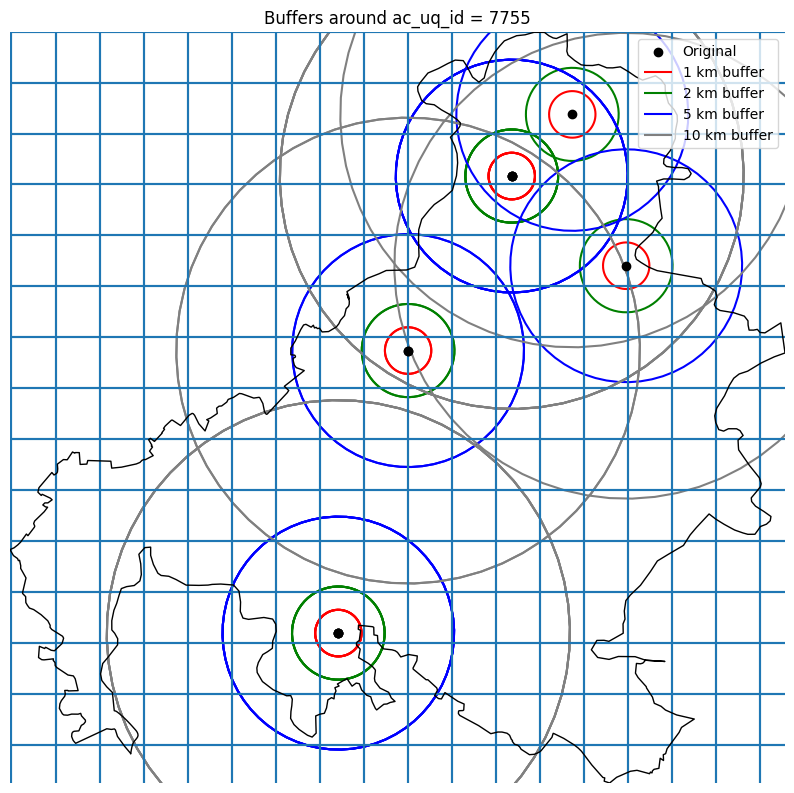

In [ ]:
import geopandas as gpd

# Step 1: Select and project geometry
geom = acs_pro.query('ac_uq_id == 433').copy()
geom_proj = geom.to_crs(epsg=7755)  # project to meters

# Step 2: Define buffer distances in kilometers
buffer_distances_km = [1, 2, 5, 10]
buffers = {}

# Step 3: Create buffers and reproject back to EPSG:4326
for dist_km in buffer_distances_km:
    buffer_gdf = geom_proj.copy()
    buffer_gdf['geometry'] = buffer_gdf.geometry.buffer(dist_km * 1000)  # convert km to meters
    buffer_gdf = buffer_gdf.to_crs(epsg=4326)
    buffers[dist_km] = buffer_gdf

minx, miny, maxx, maxy = acs.query('ac_uq_id == 433').total_bounds

# Optional: Plot all buffers
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
geom.plot(ax=ax, color='black', label='Original', zorder=5)
colors = ['red', 'green', 'blue', 'gray']
i = 0
for dist_km, buffer_gdf in buffers.items():
    buffer_gdf.boundary.plot(ax=ax, label=f'{dist_km} km buffer', color = colors[i])
    i = i + 1
grids.boundary.plot(ax=ax)
# 4. Fix the axis limits to the full-shapefile bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
acs.query('ac_uq_id == 433').boundary.plot(ax=ax, color='black', linewidth=1)
ax.legend()
ax.set_title('Buffers around ac_uq_id = 7755')
ax.axis('off')
plt.show()

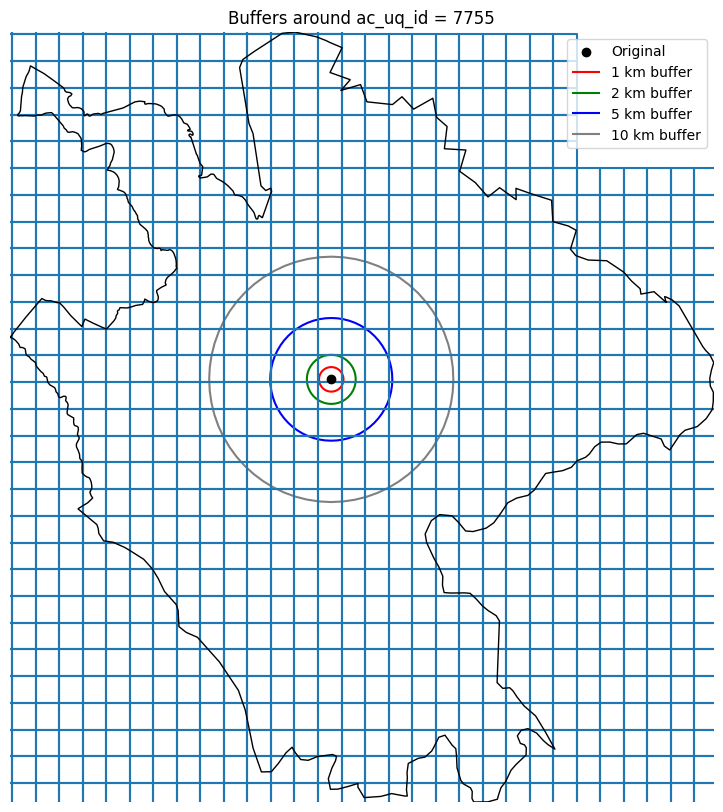

In [ ]:
import geopandas as gpd

# Step 1: Select and project geometry
geom = acs_pro.query('ac_uq_id == 689').copy()
geom_proj = geom.to_crs(epsg=7755)  # project to meters

# Step 2: Define buffer distances in kilometers
buffer_distances_km = [1, 2, 5, 10]
buffers = {}

# Step 3: Create buffers and reproject back to EPSG:4326
for dist_km in buffer_distances_km:
    buffer_gdf = geom_proj.copy()
    buffer_gdf['geometry'] = buffer_gdf.geometry.buffer(dist_km * 1000)  # convert km to meters
    buffer_gdf = buffer_gdf.to_crs(epsg=4326)
    buffers[dist_km] = buffer_gdf

minx, miny, maxx, maxy = acs.query('ac_uq_id == 689').total_bounds

# Optional: Plot all buffers
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
geom.plot(ax=ax, color='black', label='Original', zorder=5)
colors = ['red', 'green', 'blue', 'gray']
i = 0
for dist_km, buffer_gdf in buffers.items():
    buffer_gdf.boundary.plot(ax=ax, label=f'{dist_km} km buffer', color = colors[i])
    i = i + 1
grids.boundary.plot(ax=ax)
# 4. Fix the axis limits to the full-shapefile bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
acs.query('ac_uq_id == 689').boundary.plot(ax=ax, color='black', linewidth=1)
ax.legend()
ax.set_title('Buffers around ac_uq_id = 7755')
ax.axis('off')
plt.show()

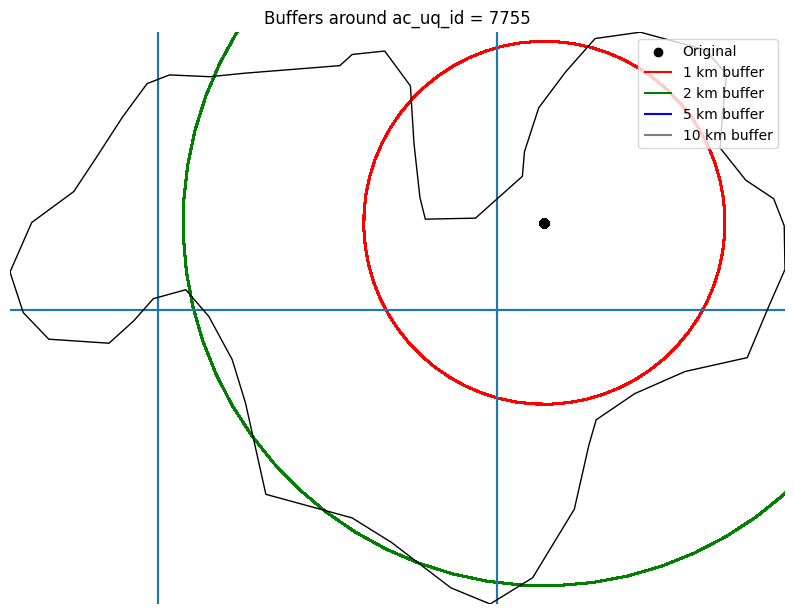

In [ ]:
import geopandas as gpd

# Step 1: Select and project geometry
geom = acs_pro.query('ac_uq_id == 334').copy()
geom_proj = geom.to_crs(epsg=7755)  # project to meters

# Step 2: Define buffer distances in kilometers
buffer_distances_km = [1, 2, 5, 10]
buffers = {}

# Step 3: Create buffers and reproject back to EPSG:4326
for dist_km in buffer_distances_km:
    buffer_gdf = geom_proj.copy()
    buffer_gdf['geometry'] = buffer_gdf.geometry.buffer(dist_km * 1000)  # convert km to meters
    buffer_gdf = buffer_gdf.to_crs(epsg=4326)
    buffers[dist_km] = buffer_gdf

minx, miny, maxx, maxy = acs.query('ac_uq_id == 334').total_bounds

# Optional: Plot all buffers
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
geom.plot(ax=ax, color='black', label='Original', zorder=5)
colors = ['red', 'green', 'blue', 'gray']
i = 0
for dist_km, buffer_gdf in buffers.items():
    buffer_gdf.boundary.plot(ax=ax, label=f'{dist_km} km buffer', color = colors[i])
    i = i + 1
grids.boundary.plot(ax=ax)
# 4. Fix the axis limits to the full-shapefile bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
acs.query('ac_uq_id == 334').boundary.plot(ax=ax, color='black', linewidth=1)
ax.legend()
ax.set_title('Buffers around ac_uq_id = 7755')
ax.axis('off')
plt.show()